# Введение в машинное обучение, АБД

## НИУ ВШЭ, 2025-26 учебный год

# Домашнее задание 1. Часть 2. Регрессия и инференс модели

Задание выполнила: Мурашкина Анастасия

    (впишите свои фамилию и имя)

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;
*  реализовать веб-сервис для применения построенной модели на новых данных

> Оценка за домашнее задание = $min(\text{ваш балл}, 33)$

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания за рамками справочной и образовательной информации генеративных моделей (ChatGPT и так далее) для генерации кода задания считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов или все баллы за соответствующее задание снимается.

## Импорт библиотек, установка констант

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [200]:
CARS_TRAIN = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_train.csv'
CARS_TEST = 'https://github.com/evgpat/datasets/raw/refs/heads/main/cars_test.csv'

In [201]:
RANDOM_STATE = 42

In [202]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Задание 0

Для чего фиксируем сиды в ноутбуке?

Для того, чтобы рандомные значения оставались фиксировнные, даже после перезапуска ячейки с кодом



## Часть 1 | EDA




Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков
- Визуализации признаков и их анализ

В следующих частях вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (4.5 балла)**

In [203]:
df_train = pd.read_csv(CARS_TRAIN)
df_test = pd.read_csv(CARS_TEST)

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(1.2 балла)**
Выполните операции, направленные на базовое исследование данных:

- [ ] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [ ] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [ ] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling) (0.15 балла)
- [ ] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла)

In [204]:
df = pd.concat([df_train, df_test])

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7999 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           7999 non-null   object 
 1   year           7999 non-null   int64  
 2   selling_price  7999 non-null   int64  
 3   km_driven      7999 non-null   int64  
 4   fuel           7999 non-null   object 
 5   seller_type    7999 non-null   object 
 6   transmission   7999 non-null   object 
 7   owner          7999 non-null   object 
 8   mileage        7778 non-null   object 
 9   engine         7778 non-null   object 
 10  max_power      7784 non-null   object 
 11  torque         7777 non-null   object 
 12  seats          7778 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 874.9+ KB


In [206]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [207]:
df.duplicated().sum()

np.int64(1170)

In [157]:
pip install fg-data-profiling

In [158]:
import data_profiling
from data_profiling import ProfileReport

ProfileReport(df, title="Profiling Report")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:01<00:00, 11.69it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Выводы: в датасете предствалены марки машин с 1983 года по 2020, цены (selling_price) на которые варьируются от 29999 до 10_000_000. При этом медиана = 450_000, что указывает на явные выбросы у правой границы.
В параметре km_driven тоже есть выбросы у правой границы.
Основная часть автомобилей была произведена с  2011 - 2018 годы и их стоимость составляет до 1_000_000 рублей. Кол-во сидений в основном - 5 штук. А средний пробег примерно до 200_000 км. Есть повторы - видимо разные машины, но с одинаковыми характеристиками


### **Задание 2 (0.6 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [210]:
df_train.describe()

,year,selling_price,km_driven,seats
count,6999.000000,6.999000e+03,6.999000e+03,6797.000000
mean,2013.818403,6.395152e+05,6.958462e+04,5.419008
std,4.053095,8.089419e+05,5.772400e+04,0.965767
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.700000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [211]:
df_test.describe()

,year,selling_price,km_driven,seats
count,1000.000000,1.000000e+03,1000.000000,981.000000
mean,2013.681000,6.179010e+05,71393.341000,5.410805
std,4.012149,7.585539e+05,48486.218662,0.919985
min,1995.000000,3.100000e+04,1303.000000,4.000000
25%,2011.000000,2.500000e+05,37000.000000,5.000000
50%,2014.000000,4.349990e+05,61500.000000,5.000000
75%,2017.000000,6.700000e+05,100000.000000,5.000000
max,2020.000000,6.000000e+06,375000.000000,9.000000


В трейне и в тесте медиана и среднее значения сильно отличаются. Медиана составляет 440-450к, когда среднее значение 640-618к. Это говорит о том, что есть выбросы в  сторону дорогих автомобилей
Такая же тенденция наблюдается в пробеге. Есть машины с аномально высоким пробегом
Кол-во мест и год выпуска особых различий не имеет

In [161]:
df_train.describe(include='object').T

,count,unique,top,freq
name,6999,1924,Maruti Swift Dzire VDI,116
fuel,6999,4,Diesel,3793
seller_type,6999,3,Individual,5826
transmission,6999,2,Manual,6095
owner,6999,5,First Owner,4587
mileage,6797,386,18.9 kmpl,197
engine,6797,120,1248 CC,885
max_power,6803,316,74 bhp,330
torque,6796,419,190Nm@ 2000rpm,468


In [212]:
df_test.describe(include='object').T

,count,unique,top,freq
name,1000,621,Maruti Alto 800 LXI,15
fuel,1000,4,Diesel,534
seller_type,1000,3,Individual,837
transmission,1000,2,Manual,877
owner,1000,5,First Owner,623
mileage,981,237,18.6 kmpl,23
engine,981,88,1248 CC,116
max_power,981,182,74 bhp,43
torque,981,226,200Nm@ 1750rpm,57


### **Задание 3 (0.6 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.05 балла)
- [ ] Отобразите такие объекты (0.05 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.05 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.05 балла)

In [216]:
not_sel = df_train.drop(['selling_price'], axis=1)

In [217]:
not_sel.duplicated().sum()

np.int64(1159)

In [218]:
not_sel.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
6994,False
6995,False
6996,False
6997,True


In [219]:
df_train = df_train.drop_duplicates(subset=not_sel, keep='first').reset_index(drop=True)

In [220]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.6 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными, они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [221]:
df_train['max_power'] = pd.to_numeric(df_train['max_power'].str.split().str[0], errors='coerce')
df_test['max_power'] = pd.to_numeric(df_test['max_power'].str.split().str[0], errors='coerce')

df_train['engine'] = pd.to_numeric(df_train['engine'].str.split().str[0], errors='coerce')
df_test['engine'] = pd.to_numeric(df_test['engine'].str.split().str[0], errors='coerce')

df_train['mileage'] = pd.to_numeric(df_train['mileage'].str.split().str[0], errors='coerce')
df_test['mileage'] = pd.to_numeric(df_test['mileage'].str.split().str[0], errors='coerce')

In [222]:
import re

def extract(value):
    if pd.isna(value):
        return None, None

    line = str(value).lower().replace(',', '')

    numbers = re.findall(r'(\d+\.?\d*)', line)

    torque = float(numbers[0])

    # Я плохо поняла, как переводить единицы измерения в нужные, поэтому ниже
    # код из нейросети

    rpms = [float(x) for x in numbers[1:] if float(x) > 500]
    max_rpm = max(rpms) if rpms else None

    if 'kgm' in line or (torque < 50 and 'nm' not in line):
        torque = torque * 9.81

    return torque, max_rpm

df_train[['torque', 'max_torque_rpm']] = df_train['torque'].apply(
    lambda x: pd.Series(extract(x))
)

df_test[['torque', 'max_torque_rpm']] = df_test['torque'].apply(
    lambda x: pd.Series(extract(x))
)

### **Задание 5 (0.6 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [ ] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [ ] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`






In [223]:
list_none = df_train.columns[df_train.isnull().any()].tolist()

In [224]:
for i in list_none:
  mediana_train = df_train[i].median()

  df_train[i] = df_train[i].fillna(mediana_train)
  df_test[i] = df_test[i].fillna(mediana_train)

In [225]:
print(f'Пропуски в трейне {df_train.isnull().sum().sum()}')
print(f'Пропуски в тесте {df_test.isnull().sum().sum()}')

Пропуски в трейне 0
Пропуски в тесте 0


Лучше использовать медиану, т.к. она лучше описывает среднее значения, ведь у нас не нормальное распределние значений
При этом медиана используется только из train, т.к. по тестовым данным мы проверяем точность работы модели, если использоваь медиану из теста, то результаты модели будут завышенными

### **Задание 6 (0.6 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.
- [ ] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [226]:
df_test[['engine', 'seats']] = df_test[['engine', 'seats']].astype(int)
df_train[['engine', 'seats']] = df_train[['engine', 'seats']].astype(int)

т.к. кол-во сидений влияет напрямую на тип автомобиля. Например, если сидений 14 - это может быть автобус, если 2 - спорткар и тд. Значит это разные категории автомобилей

### **Задание 7 (0.3 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [227]:
df_train.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.430841,1429.448973,87.906371,175.935918,5.426712,3045.789041
std,4.095622,5.354320e+05,6.007114e+04,3.985973,485.662834,31.640418,116.779426,0.982344,911.039323
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,47.088000,2.000000,1400.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,111.800000,5.000000,2250.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.370000,1248.000000,81.860000,160.000000,5.000000,3000.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,200.124000,5.000000,4000.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,3727.800000,14.000000,21800.000000


In [228]:
df_test.describe()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
count,1000.000000,1.000000e+03,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,2013.681000,6.179010e+05,71393.341000,19.33881,1454.87600,90.841670,177.621834,5.403000,3098.27600
std,4.012149,7.585539e+05,48486.218662,3.95175,521.99574,34.893389,103.745986,0.912921,877.14712
min,1995.000000,3.100000e+04,1303.000000,0.00000,624.00000,34.200000,48.000000,4.000000,1500.00000
25%,2011.000000,2.500000e+05,37000.000000,16.55000,1197.00000,69.000000,111.700000,5.000000,2500.00000
50%,2014.000000,4.349990e+05,61500.000000,19.37000,1248.00000,82.425000,160.000000,5.000000,3000.00000
75%,2017.000000,6.700000e+05,100000.000000,22.30000,1582.00000,102.000000,205.000000,5.000000,4000.00000
max,2020.000000,6.000000e+06,375000.000000,32.26000,3604.00000,280.000000,1422.450000,9.000000,5200.00000


да, т.к. мы повлияли на кол-во тех или иных значений, данные становятся более скученные рядом с медианой. Но, с другой стороны, пропусков было не так много, поэтому влияние было не таким сильным

## **Визуализации и корреляция (4.8 балла + 0.3)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (1.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

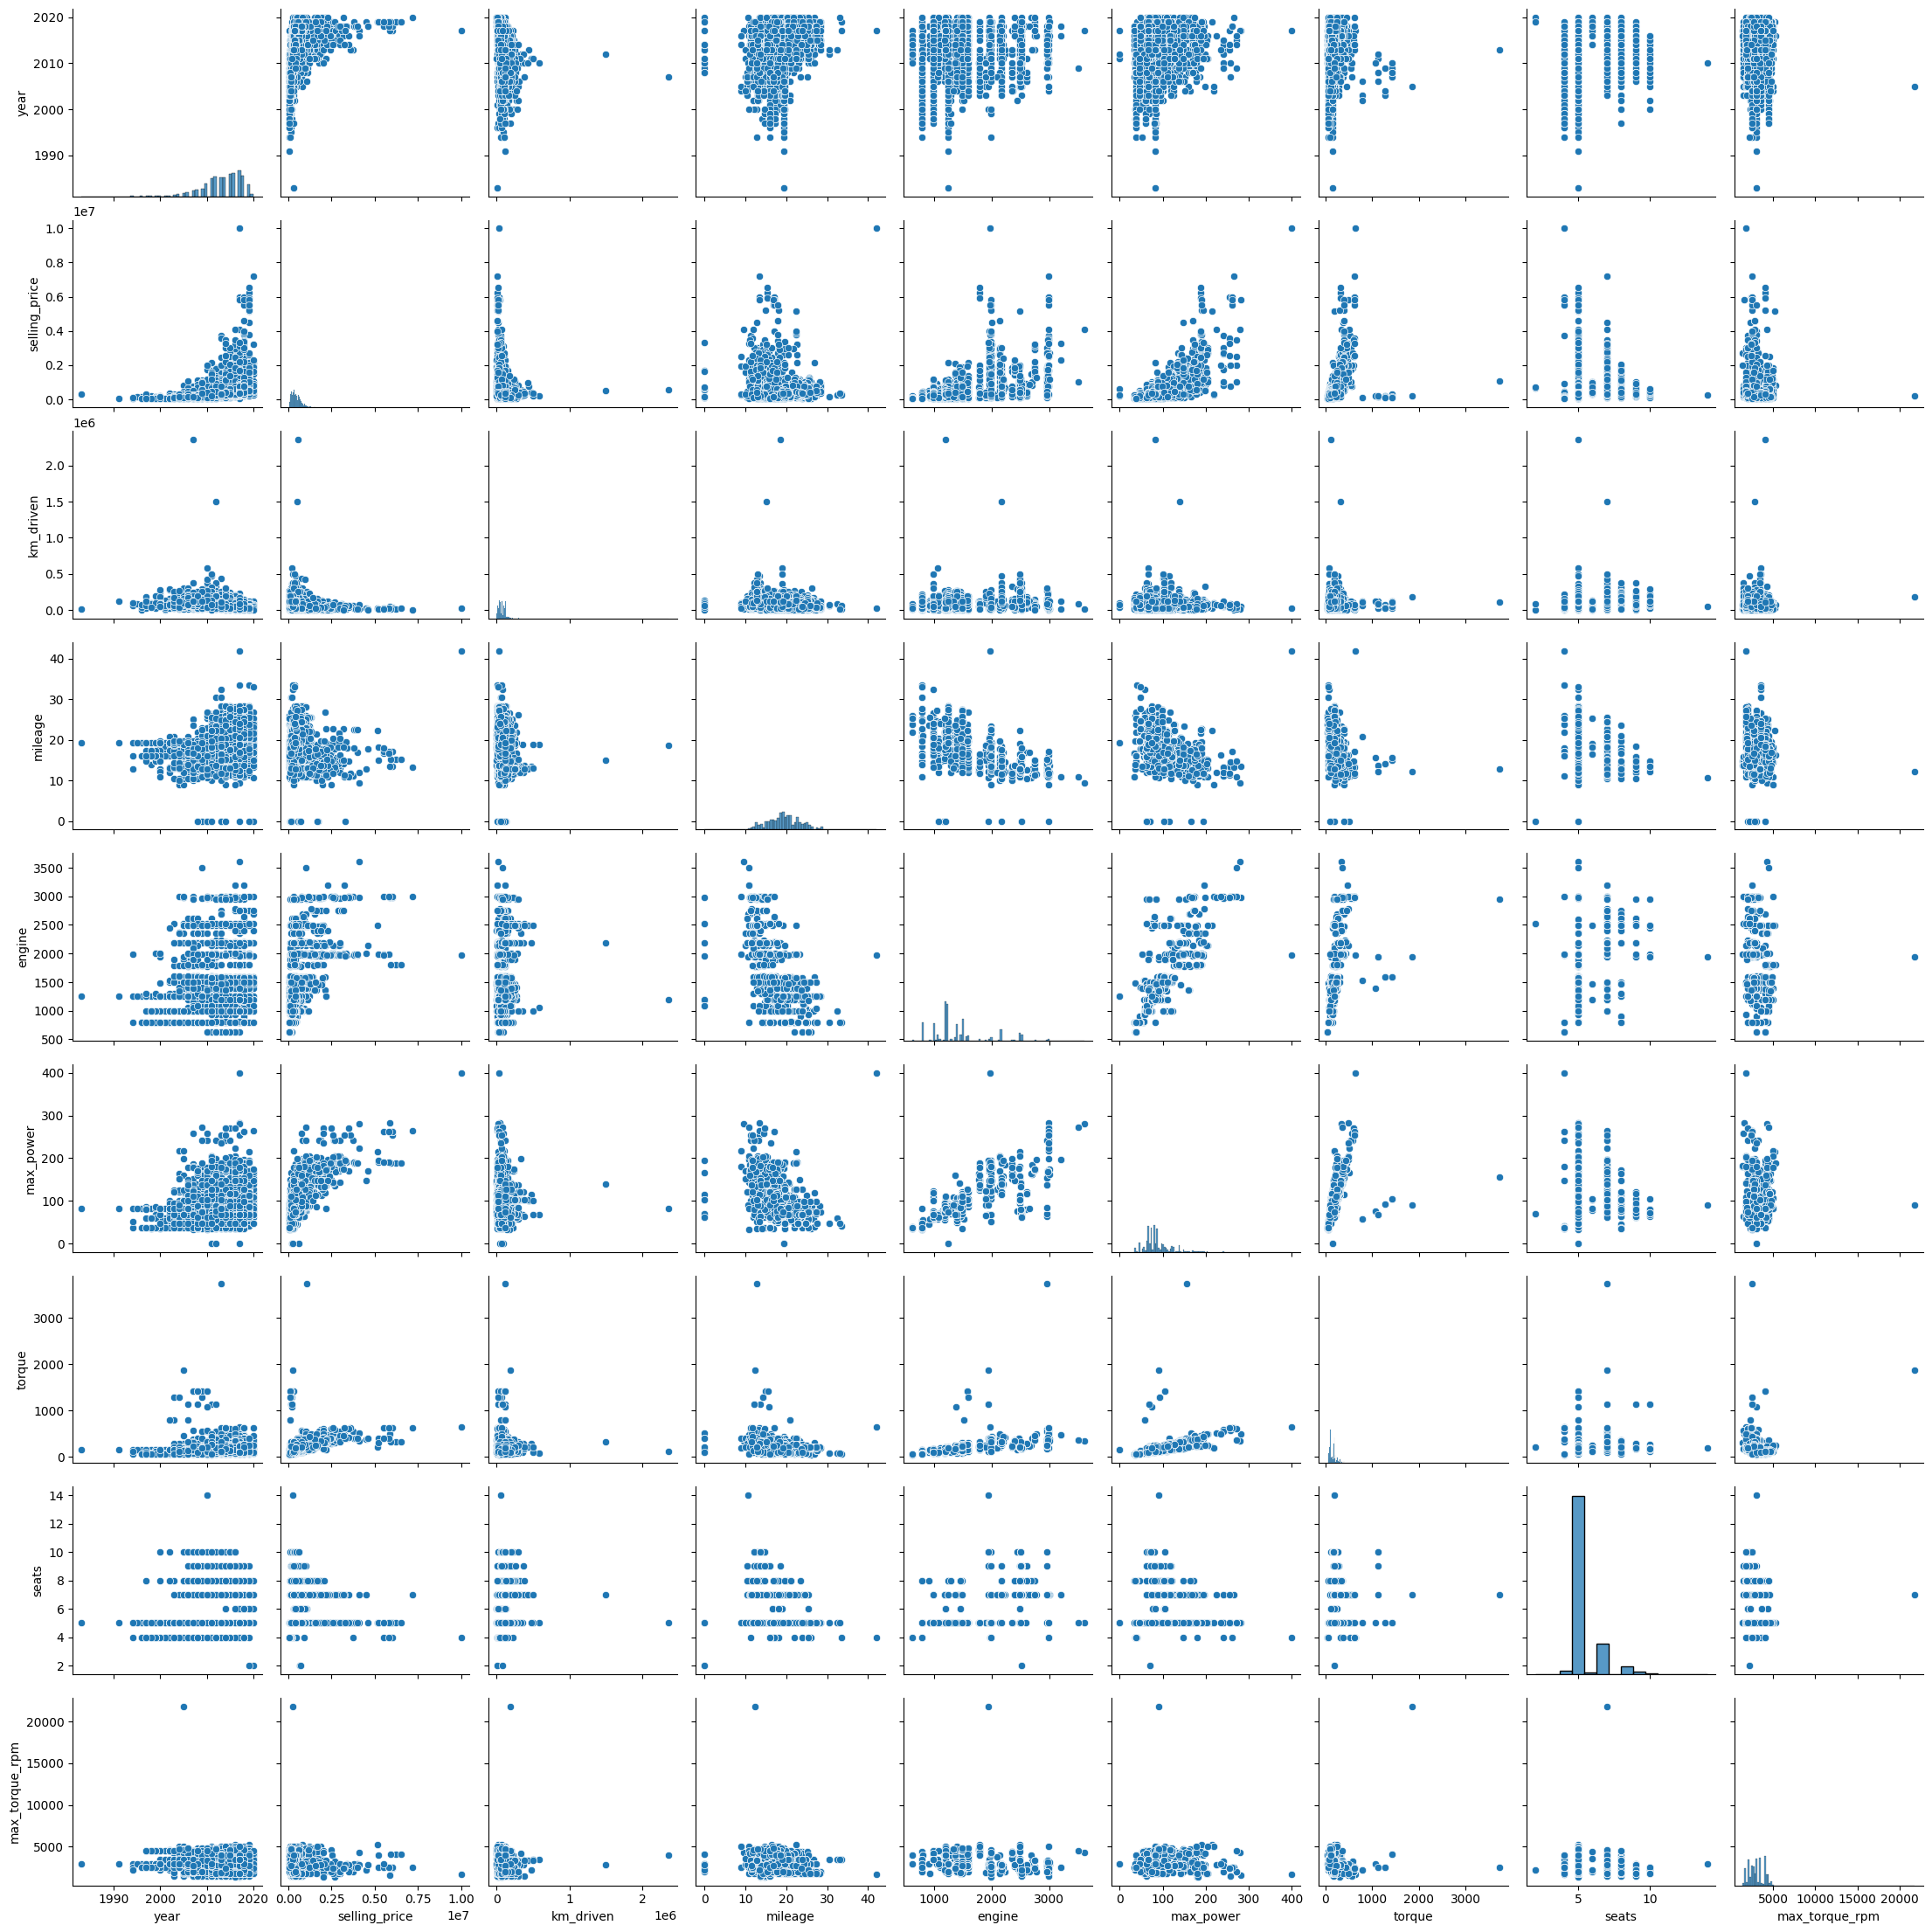

In [176]:
sns.pairplot(df_train)

Есть связь между ценой и годом выпуска(чем новее машина, тем дороже), зависимость между ценой и максимальной мощностью выглядит, как линейная. Видно, что, чем больше пробег, тем меньше стоимость. Объем двигателя тоже влияет на стоимость, но зависимость не такая четкая

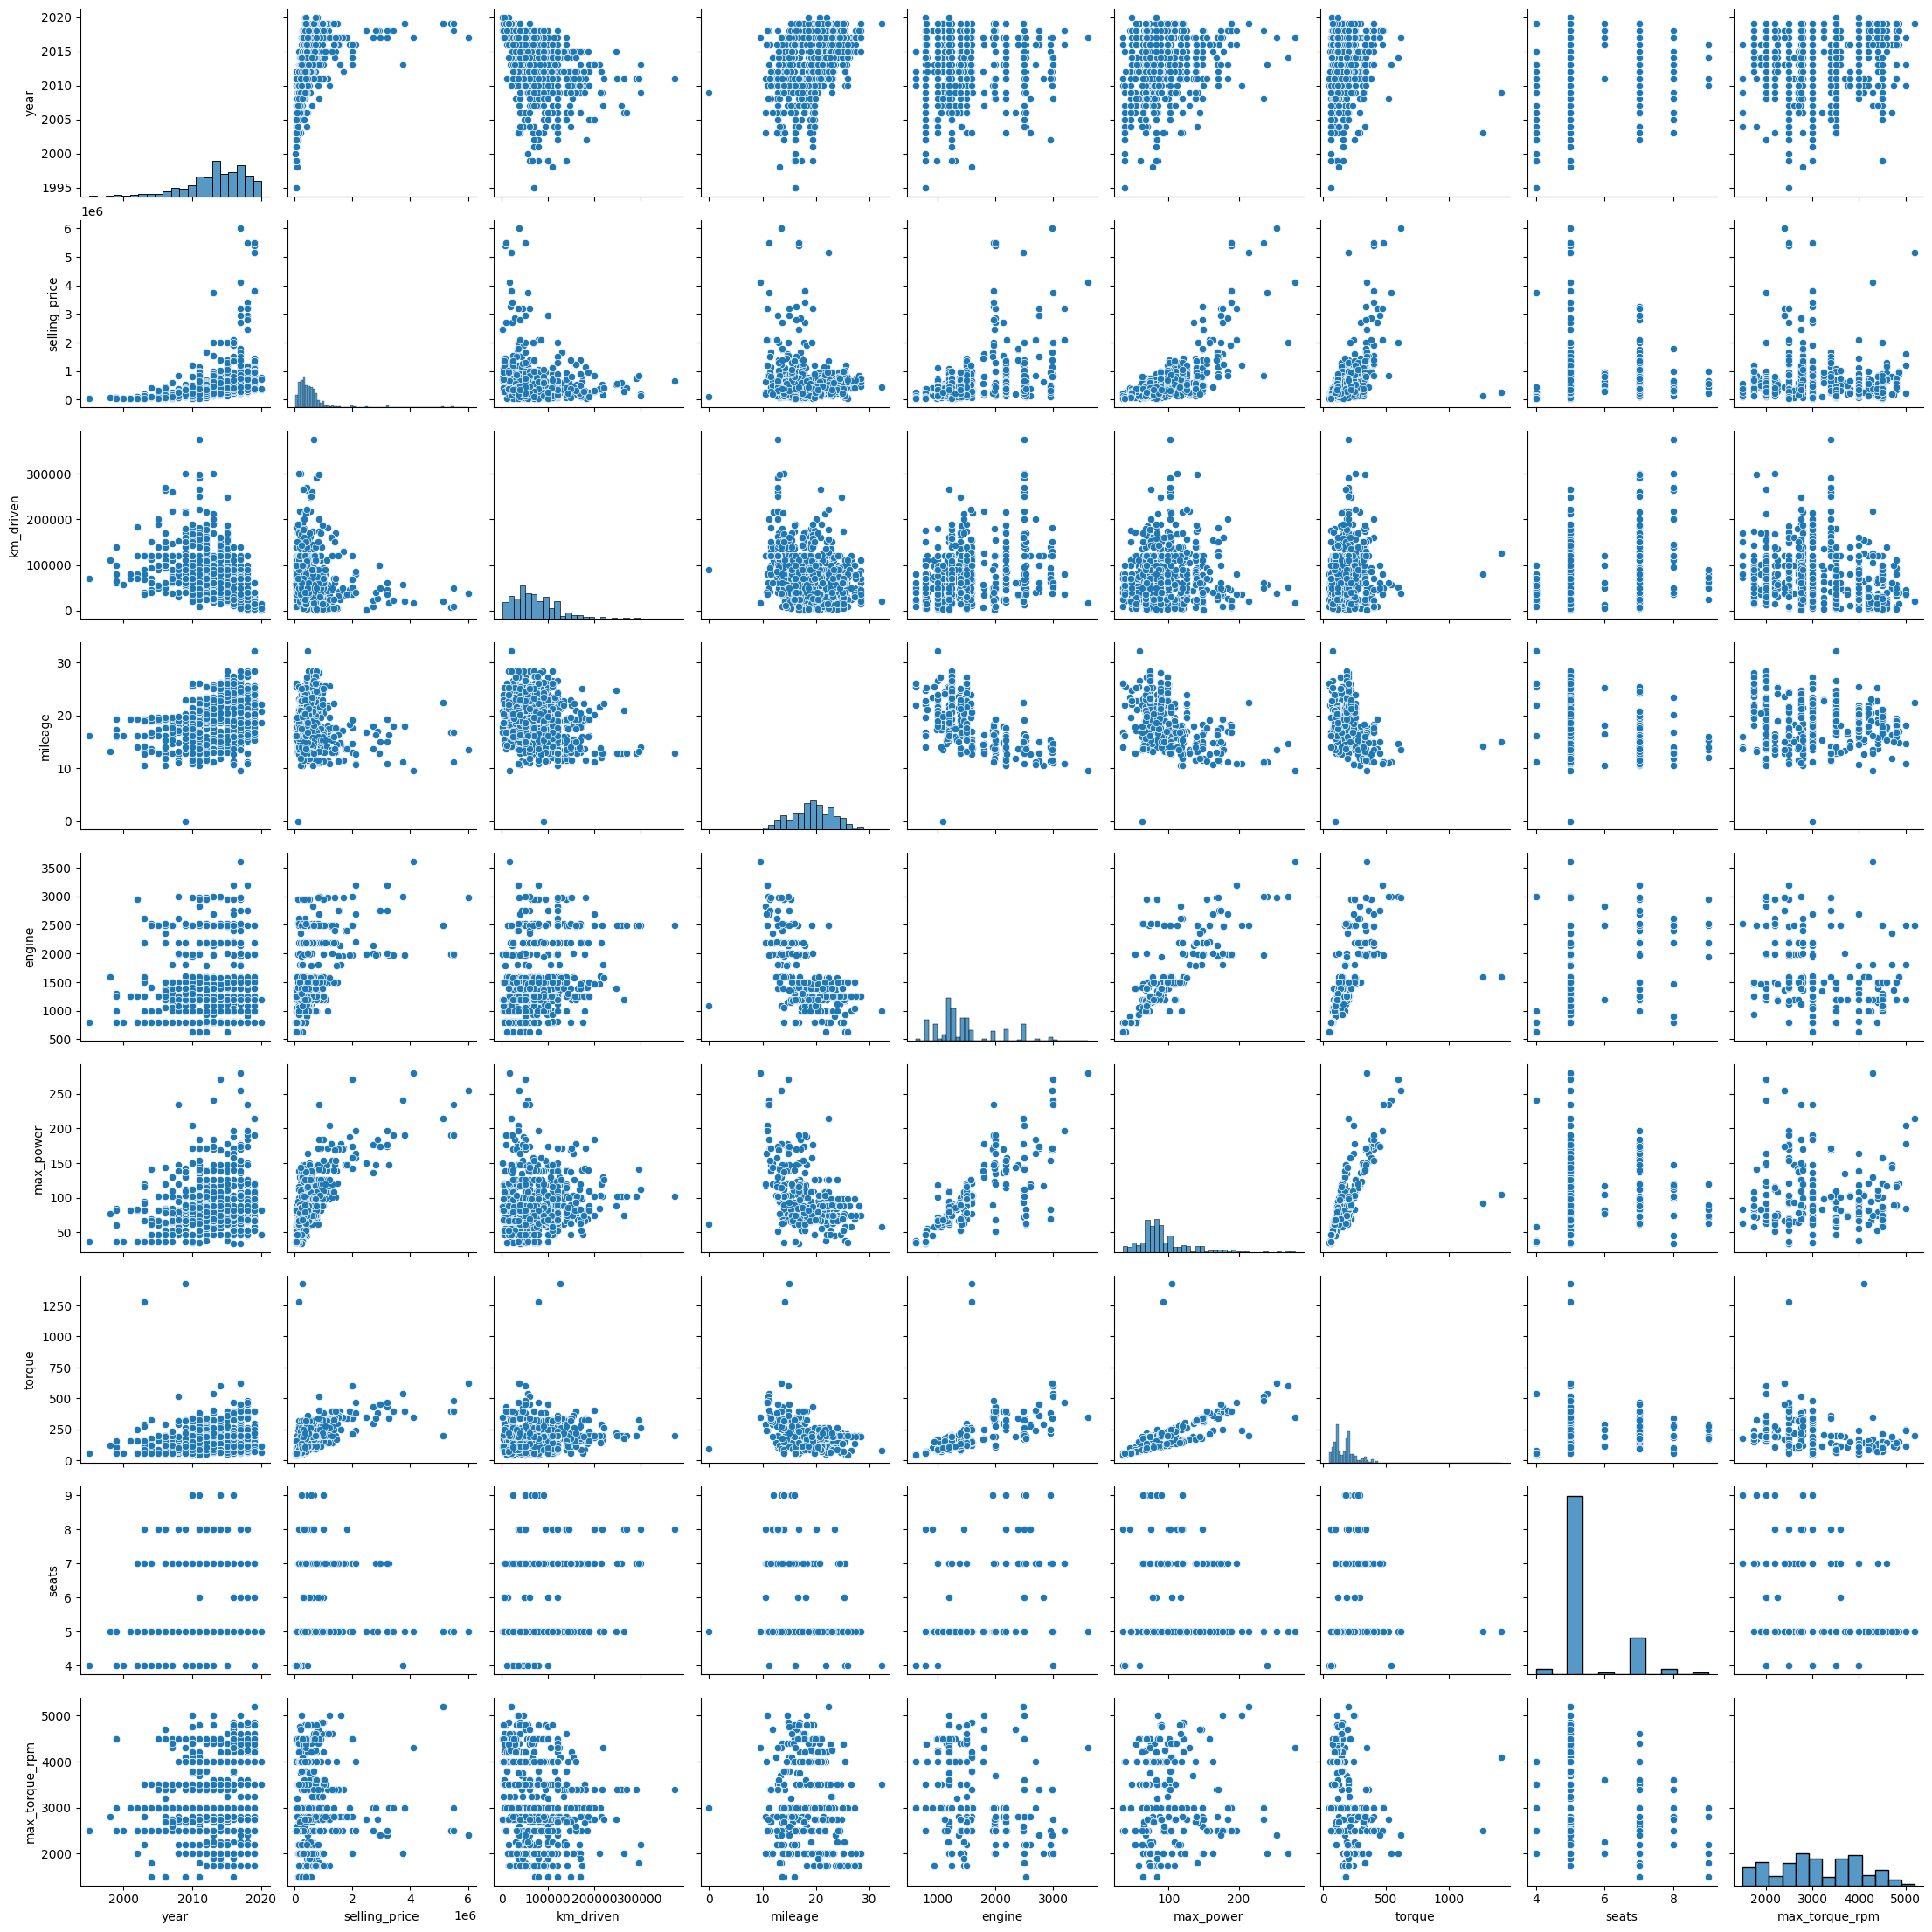

In [177]:
sns.pairplot(df_test)

Некоторые графики похожи, но учитывая разное кол-во данных и выбросы на некоторых, какая-то часть графиков различается

### **Задание 9 (1.5 балла)**

Итак, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

In [229]:
df_train.corr(numeric_only=True)

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
year,1.000000,0.427279,-0.368966,0.341334,0.002819,0.156858,0.048198,0.041178,0.048700
selling_price,0.427279,1.000000,-0.164828,-0.104769,0.447672,0.692814,0.433026,0.149953,-0.088043
km_driven,-0.368966,-0.164828,1.000000,-0.182086,0.229766,0.024588,0.106611,0.192328,-0.204337
mileage,0.341334,-0.104769,-0.182086,1.000000,-0.572893,-0.373390,-0.226224,-0.451059,-0.181071
engine,0.002819,0.447672,0.229766,-0.572893,1.000000,0.681117,0.565994,0.652172,-0.244928
max_power,0.156858,0.692814,0.024588,-0.373390,0.681117,1.000000,0.616096,0.244112,-0.019995
torque,0.048198,0.433026,0.106611,-0.226224,0.565994,0.616096,1.000000,0.298063,-0.248888
seats,0.041178,0.149953,0.192328,-0.451059,0.652172,0.244112,0.298063,1.000000,-0.206261
max_torque_rpm,0.048700,-0.088043,-0.204337,-0.181071,-0.244928,-0.019995,-0.248888,-0.206261,1.000000


<Axes: >

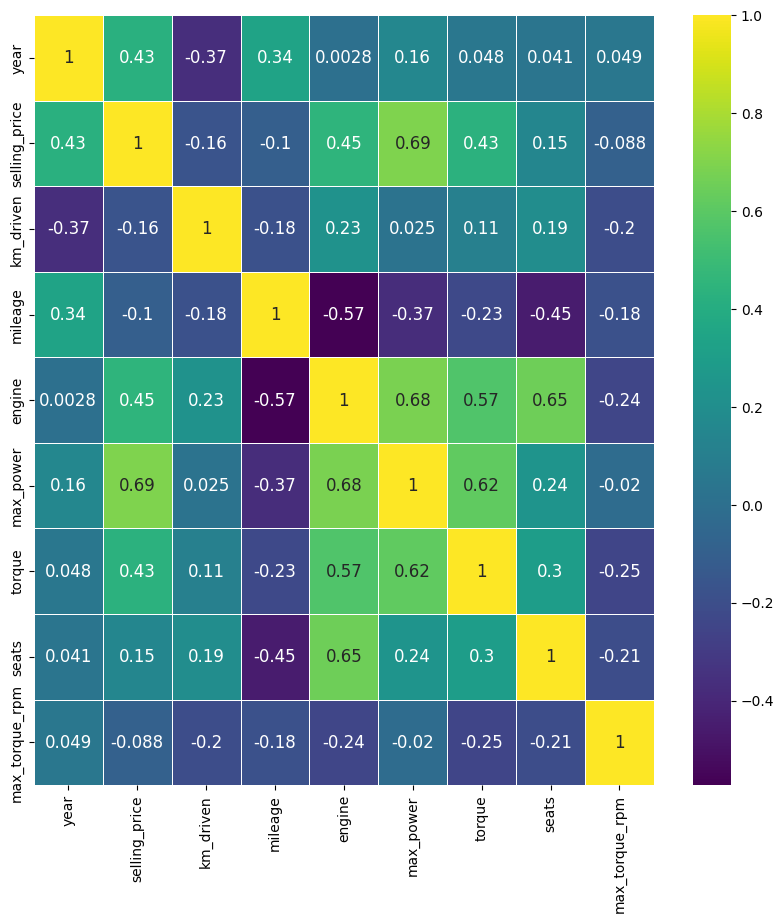

In [230]:
fig , ax = plt.subplots(figsize = (10,10))

sns.heatmap(df_train.corr(numeric_only=True),
            linewidths=0.5, annot=True,cmap='viridis',
            linecolor="white", annot_kws = {'size':12})

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

1. Year, engine
2. selling_price, max_power и engine и max_power
3. тк. коэффициет равен -0,37, значит если год увеличивается, то пробег уменьшается

### **Задание 10 (1.8 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией
- [ ]

Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


`Your answer here`

### **Дополнительные визуализации (0.3 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.

# **Часть 2 (5.4 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.15 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [231]:
df_train_copy = df_train.select_dtypes(include=['number']).copy()
df_test_copy = df_test.select_dtypes(include=['number']).copy()

In [232]:
y_train = df_train_copy['selling_price']
X_train = df_train_copy.drop(columns=['selling_price'])

In [233]:
X_train

,year,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
0,2014,145500,23.40,1248,74.00,190.000,5,2000.0
1,2014,120000,21.14,1498,103.52,250.000,5,2500.0
2,2010,127000,23.00,1396,90.00,219.744,5,2750.0
3,2007,120000,16.10,1298,88.20,112.815,5,4500.0
4,2017,45000,20.14,1197,81.86,113.750,5,4000.0
...,...,...,...,...,...,...,...,...
5835,2008,191000,17.92,1086,62.10,96.100,5,3000.0
5836,2013,50000,18.90,998,67.10,90.000,5,3500.0
5837,2013,110000,18.50,1197,82.85,113.700,5,4000.0
5838,2007,119000,16.80,1493,110.00,235.440,5,2750.0


In [234]:
assert X_train.shape == (5840, 8)

In [235]:
y_test = df_test_copy['selling_price']
X_test = df_test_copy.drop(columns=['selling_price'])

In [236]:
assert X_test.shape == (1000, 8)

### **Задание 12. (0.6 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [237]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE, root_mean_squared_error as RMSE

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [238]:
pred_train = lr.predict(X_train)
print(f'MSE: {MSE(y_train, pred_train)}')
print(f'R2: {round(r2_score(y_train, pred_train), 5)}')

MSE: 114349087665.60304
R2: 0.60107


In [239]:
pred_test = lr.predict(X_test)
print(f'MSE: {MSE(y_test, pred_test)}')
print(f'R2: {round(r2_score(y_test, pred_test), 5)}')

MSE: 229669110505.37686
R2: 0.60046


Cудя по метрике R2 модель угадывает в чуть больше, чем в половине случаев. При этом тенденция сохраняется и в трейне, и в тесте. А вот MSE слишком большая. Лучше найти RMSE, для лучшего понимания

In [240]:
print(f'RMSE train: {round(RMSE(y_train, pred_train), 5)}')
print(f'RMSE test: {round(RMSE(y_test, pred_test), 5)}')

RMSE train: 338155.41939
RMSE test: 479238.05202


Видно, что средняя ошибка = 340000 в трейне, а в тесте еще больше. Это слишком большая погрешность, т.к. стоимость некоторых автомобилей, как раз находится в этом диапазоне

### **Задание 13 (0.45 балла)**

- [ ] Реализуйте $R^2$ руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

$$R^2(a, X, Y) = 1 - \frac {\sum^L_{i=1}(a(x_i) - y_i)^2}{\sum^L_{i=1}(y_i - \bar{y})^2}$$

In [241]:
def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    y_mean = np.mean(y_true)

    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - y_mean) ** 2)

    r2 = 1 - (numerator / denominator)
    return r2

L - размер выборки   
i - индекс объекта выборки   
xi - вектор признаков   
yi - истинное значение целевой переменной   
a(xi) - предсказание для xi   
y- -  среднее арифметическое всех правильных предсказаний целевой переменной

L - объем выборки i - индекс конкретного объекта выборки
xi - вектор признаков
yi - фактическое значение целевой переменной
a(xi) — предсказание
y — среднее арифметическое всех истинных ответов целевой переменной


### **Бонус (0.45 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [242]:
def adjusted_r2(y_true, y_pred, k):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n = len(y_true)

# r2
    y_mean = np.mean(y_true)
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - y_mean) ** 2)

    r2 = 1 - (numerator / denominator)

# Adjusted R2
    ad_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    return ad_r2

adjusted − R2 позврляет понять - улучшается ли модель при добавлении новой переменной (реально ли увеличится r2) Т.к. r2 всегда увеличивается при добавлении переменной

### **Задание 14 (0.45 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

Как изменилось качество модели?

In [243]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
train_x_scaler = scaler.transform(X_train)
test_x_scaler = scaler.transform(X_test)

lr2 = LinearRegression()
lr2.fit(train_x_scaler, y_train)

pred_train2 = lr2.predict(train_x_scaler)
pred_test2 = lr2.predict(test_x_scaler)

print(f'MSE train: {MSE(y_train, pred_train2)}')
print(f'R2 train: {round(r2_score(y_train, pred_train2), 5)}')
print(f'RMSE train: {round(RMSE(y_train, pred_train2), 5)}')
print()
print(f'MSE test: {MSE(y_test, pred_test2)}')
print(f'R2 test: {round(r2_score(y_test, pred_test2), 5)}')
print(f'RMSE test: {round(RMSE(y_test, pred_test2), 5)}')

MSE train: 114349087665.60309
R2 train: 0.60107
RMSE train: 338155.41939

MSE test: 229669110505.37808
R2 test: 0.60046
RMSE test: 479238.05202


Ничего не изменилось, т.к. скалирование не влияет на качество предсказания линейной регрессии

### **Задание 15 (0.3 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве, она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

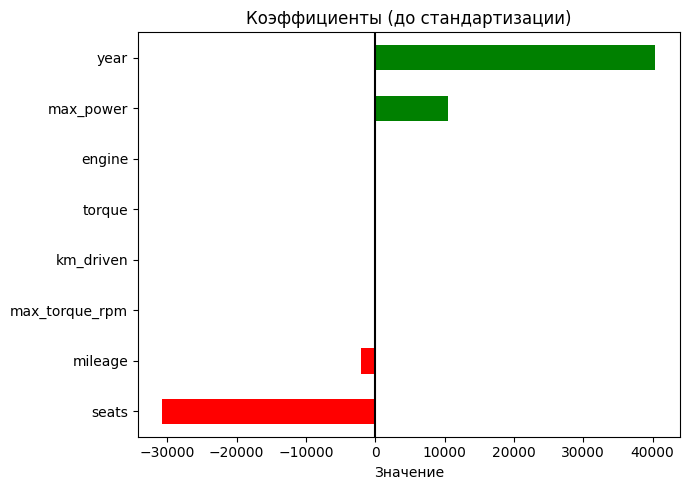

In [244]:
coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values()
plt.figure(figsize=(7, 5))
coefs.plot(kind='barh', color=['red' if x < 0 else 'green' for x in coefs])
plt.axvline(0, color='black')
plt.title('Коэффициенты (до стандартизации)')
plt.xlabel('Значение')
plt.tight_layout()
plt.show()

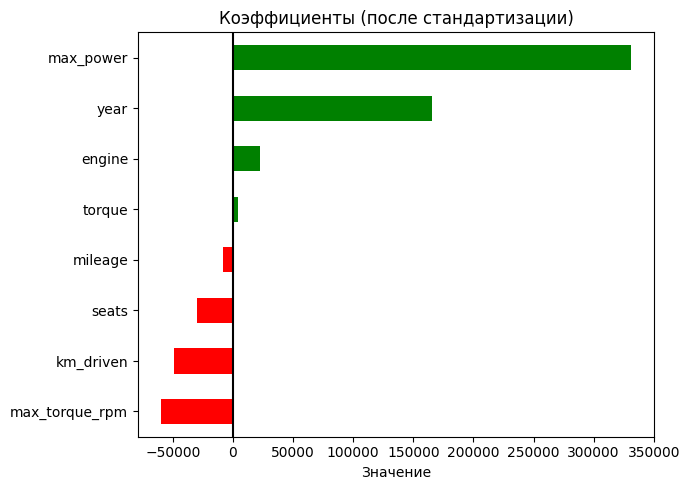

In [245]:
coefs = pd.Series(lr2.coef_, index=X_train.columns).sort_values()
plt.figure(figsize=(7, 5))
coefs.plot(kind='barh', color=['red' if x < 0 else 'green' for x in coefs])
plt.axvline(0, color='black')
plt.title('Коэффициенты (после стандартизации)')
plt.xlabel('Значение')
plt.tight_layout()
plt.show()

Самый важный признак - максимальная мощность

### **Задание 16 (0.75 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [246]:
from sklearn.linear_model import Lasso

lr_lasso = Lasso()
lr_lasso.fit(train_x_scaler, y_train)

pred_train_lasso = lr_lasso.predict(train_x_scaler)
pred_test_lasso = lr_lasso.predict(test_x_scaler)

print(f'MSE train: {MSE(y_train, pred_train_lasso)}')
print(f'R2 train: {round(r2_score(y_train, pred_train_lasso), 5)}')
print(f'RMSE train: {round(RMSE(y_train, pred_train_lasso), 5)}')
print()
print(f'MSE test: {MSE(y_test, pred_test_lasso)}')
print(f'R2 test: {round(r2_score(y_test, pred_test_lasso), 5)}')
print(f'RMSE test: {round(RMSE(y_test, pred_test_lasso), 5)}')

MSE train: 114349087679.22977
R2 train: 0.60107
RMSE train: 338155.41941

MSE test: 229669848438.47464
R2 test: 0.60046
RMSE test: 479238.82192


In [247]:
lr_lasso.coef_

array([165427.77150721, -48942.85862435,  -8125.28835556,  22924.65599411,
       330865.58858366,   4595.33516847, -30142.71895757, -59507.3011179 ])

Качество модели не изменилось. Lasso не занулила ни одного признака. Может значение коэффициента альфа по умолчанию не походит для достаточного зануления

### **Задание 17. Финальный рывок (1.2 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [248]:
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-2, 3, 20)
searcher = GridSearchCV(
    Lasso(),
     [{"alpha": alphas}],
    scoring="r2",
    cv=10)

searcher.fit(train_x_scaler, y_train)

best_alpha = searcher.best_params_["alpha"]
print("Best alpha = %.4f" % best_alpha)

Best alpha = 1000.0000


In [249]:
lr_lasso_best_alpha = Lasso(alpha=best_alpha)
lr_lasso_best_alpha.fit(train_x_scaler, y_train)

pred_train_lasso_best_alpha = lr_lasso_best_alpha.predict(train_x_scaler)
pred_test_lasso_best_alpha = lr_lasso_best_alpha.predict(test_x_scaler)

print(f'MSE train: {MSE(y_train, pred_train_lasso_best_alpha)}')
print(f'R2 train: {round(r2_score(y_train, pred_train_lasso_best_alpha), 5)}')
print(f'RMSE train: {round(RMSE(y_train, pred_train_lasso_best_alpha), 5)}')
print()
print(f'MSE test: {MSE(y_test, pred_test_lasso_best_alpha)}')
print(f'R2 test: {round(r2_score(y_test, pred_test_lasso_best_alpha), 5)}')
print(f'RMSE test: {round(RMSE(y_test, pred_test_lasso_best_alpha), 5)}')

MSE train: 114363193836.5432
R2 train: 0.60102
RMSE train: 338176.27628

MSE test: 230422430926.13544
R2 test: 0.59915
RMSE test: 480023.36498


In [250]:
lr_lasso_best_alpha.coef_

array([163122.85664225, -48026.45340169,  -4660.27964069,  21062.94393773,
       332228.07033078,   3955.41071236, -26140.97267552, -57343.99172631])

1. 200 моделей (10 фолдов * 20 значений альфа)
2. alpha - коэффициент для Lasso, scoring -  метрика для оценки модели, сv - кол-во фолдов
3. Лучший коэффициент = 1000, но веса все равно не занулились

**Ваша задача 2:**

- [ ] Перебором по сетке (c десятью фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [251]:
from sklearn.linear_model import ElasticNet

param_grid = {
    'alpha': np.arange(0.5, 2.1, 0.1).tolist(),
    'l1_ratio': np.arange(0.0, 1.1, 0.1).tolist()
}

searcher = GridSearchCV(
    ElasticNet(),
    param_grid=param_grid,
    scoring="r2",
    cv=10)

searcher.fit(train_x_scaler, y_train)

best_alpha_elsatic = searcher.best_params_["alpha"]
best_l1_ratio_elsatic = searcher.best_params_["l1_ratio"]

print("Best alpha = %.4f" % best_alpha_elsatic)
print("Best l1_ratio = %.4f" % best_l1_ratio_elsatic)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.440e+14, tolerance: 1.247e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.298e+14, tolerance: 1.564e+11 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

Best alpha = 1.1000
Best l1_ratio = 0.9000


1. 1760 моделей (10 фолдов * 16 значений альфа * 11 l1_ratio)
2. Best alpha = 1.1
Best l1_ratio = 0.9

In [252]:
lr_elasticnet = ElasticNet(alpha=best_alpha_elsatic, l1_ratio=best_l1_ratio_elsatic)
lr_elasticnet.fit(train_x_scaler, y_train)

pred_train_elasticnet = lr_elasticnet.predict(train_x_scaler)
pred_test_elasticnet = lr_elasticnet.predict(test_x_scaler)

print(f'MSE train: {MSE(y_train, pred_train_elasticnet)}')
print(f'R2 train: {round(r2_score(y_train, pred_train_elasticnet), 5)}')
print(f'RMSE train: {round(RMSE(y_train, pred_train_elasticnet), 5)}')
print()
print(f'MSE test: {MSE(y_test, pred_test_elasticnet)}')
print(f'R2 test: {round(r2_score(y_test, pred_test_elasticnet), 5)}')
print(f'RMSE test: {round(RMSE(y_test, pred_test_elasticnet), 5)}')

MSE train: 116160644758.53897
R2 train: 0.59475
RMSE train: 340823.48035

MSE test: 244224365415.3562
R2 test: 0.57514
RMSE test: 494190.61648


### **Задание 18 (1.05 балла)**

Итак, вы обучили все варианты регуляризаций, доступные в sklearn, но есть и другие варианты! И следующее задание о забытой $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



In [ ]:
# your code here

# **Часть 3 (1.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.5 основных балла.



### **Задание 19 (0.3 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

Всего 30 уникальных наименований марок, это слишком много, чтобы делать столбец name категориальным. Если брать отедльную категорию other при кол-ве машин конкретной марки < 5, то останется 22 марки. Но грубо объединять Lexus и Kia в одну категорию, хоть они встречаются меньше 5 раз. У них слишком разная стоимость автомобилей. Вероятно, имеет смысл заменить name на числовое осознанное значение. Например, среднюю стоимость машин конкретной марки. Это можно сделать через category_encoders

In [253]:
!pip install category_encoders

ERROR: Operation cancelled by user


In [254]:
X_train_cat = df_train.copy()
X_test_cat = df_test.copy()

X_train_cat['name'] = X_train_cat['name'].str.split().str[0]
X_test_cat['name'] = X_test_cat['name'].str.split().str[0]

In [255]:
from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=['name'])

encoder.fit(X_train_cat['name'], y_train)
X_train_cat['name'] = encoder.transform(X_train_cat['name'])

X_test_cat['name'] = encoder.transform(X_test_cat['name'])

In [256]:
X_train_cat = X_train_cat.drop(['selling_price'], axis=1)

In [257]:
assert X_train_cat.shape == (5840, 13)

In [258]:
X_train_cat.describe(include='object')

,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840
unique,4,3,2,5
top,Diesel,Individual,Manual,First Owner
freq,3177,5223,5336,3603


### **Задание 20 (0.3 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [259]:
from sklearn.preprocessing import OneHotEncoder

X_train_dum = pd.get_dummies(X_train_cat, columns=['fuel', 'transmission', 'seller_type', 'owner'], dtype=int, drop_first=True)
X_test_dum = pd.get_dummies(X_test_cat, columns=['fuel', 'transmission', 'seller_type', 'owner'], dtype=int, drop_first=True)

Я решила разбить не на 14 категорий seats, а на 1-2, 4-5, 6-8, 9-14

In [260]:
seat_bins = [1, 2, 5, 8, 14]

seat_labels = ['2', '4-5', '6-8', '9-14']

X_train_dum['seats_cat'] = pd.cut(X_train_dum['seats'], bins=seat_bins, labels=seat_labels)
X_test_dum['seats_cat'] = pd.cut(X_test_dum['seats'], bins=seat_bins, labels=seat_labels)

X_train_dum = pd.get_dummies(X_train_dum.drop(columns=['seats']), columns=['seats_cat'], prefix='seats', dtype=int, drop_first=True)
X_test_dum = pd.get_dummies(X_test_dum.drop(columns=['seats']), columns=['seats_cat'], prefix='seats', dtype=int, drop_first=True)

X_test_dum = X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)

### **Задание 21 (0.6 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

1. Fit призводится только на трейн выборке, необходимо удалять исходный столбец, не стоит кодировать столбец, если в нем слишком много уникальных значений. использовать drop_first=True
2. Для предотаврщения мультиколлинираности. Если в данных будет, например 0 0 0, то модель поймет, что признак попал в 4ую категорию. Это работает для линейной регрессии
3. Нет, тогда модель будет приравнивать эти удаленные столбцы к одной категории с тем самым первым удлаенным признаком

### **Задание 22 (0.3 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [261]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train_dum)
train_x_scaler_dum = scaler.transform(X_train_dum)
test_x_scaler_dum = scaler.transform(X_test_dum)

In [262]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': np.arange(0.5, 2.1, 0.1).tolist()
}

searcher = GridSearchCV(
    Ridge(),
    param_grid=param_grid,
    scoring="r2",
    cv=10)

searcher.fit(train_x_scaler_dum, y_train)

best_alpha = searcher.best_params_["alpha"]

print("Best alpha = %.4f" % best_alpha)

Best alpha = 2.0000


In [263]:
best_ridge_model = searcher.best_estimator_
pred_train_ridge = best_ridge_model.predict(train_x_scaler_dum)
pred_test_ridge = best_ridge_model.predict(test_x_scaler_dum)

print(f'MSE train: {MSE(y_train, pred_train_ridge):.5f}')
print(f'R2 train: {round(r2_score(y_train, pred_train_ridge), 5)}')
print(f'RMSE train: {RMSE(y_train, pred_train_ridge):.5f}')
print()
print(f'MSE test: {MSE(y_test, pred_test_ridge):.5f}')
print(f'R2 test: {round(r2_score(y_test, pred_test_ridge), 5)}')
print(f'RMSE test: {RMSE(y_test, pred_test_ridge):.5f}')

MSE train: 78836908027.98468
R2 train: 0.72496
RMSE train: 280779.10896

MSE test: 171472478658.71100
R2 test: 0.7017
RMSE test: 414092.35523


Да, качество предсказаний улучшилось. Все метрики стали лучше r2 с 60% до 70%. Хя средняя ошибка все равно высокая, я это связываю с тем, что не было работы с выбросами

# **Часть 4 - бонусная (3 балла) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый уникальный пункт по 0.6 балла, но не больше трех баллов в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*

  * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
  * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*

  * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
  * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*

  * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
  * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
  * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
  * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

В этом пункте также оценивается целесообразность и пояснение выбранного вами метода или методов.

In [264]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

##### 1. Новый признак power_per_liter

Из heatmap выше видно, что зависимость между engine и max_power = 0,68, engine и torque = 0,57,  max_power и torque = 0.62. Можно доавбить новый признак 'лошади на литр', далее удлаить engine, чтобы избавиться от мультиколлинеарности

In [265]:
df_train_eng = df_train.copy()
df_test_eng = df_test.copy()

df_train_eng['power_per_liter'] = df_train_eng['max_power'] / (df_train_eng['engine'] / 1000)
df_test_eng['power_per_liter'] = df_test_eng['max_power'] / (df_test_eng['engine'] / 1000)


df_train_eng.drop(columns=['max_torque_rpm', 'engine'], inplace=True)
df_test_eng.drop(columns=['max_torque_rpm', 'engine'], inplace=True)

<Axes: >

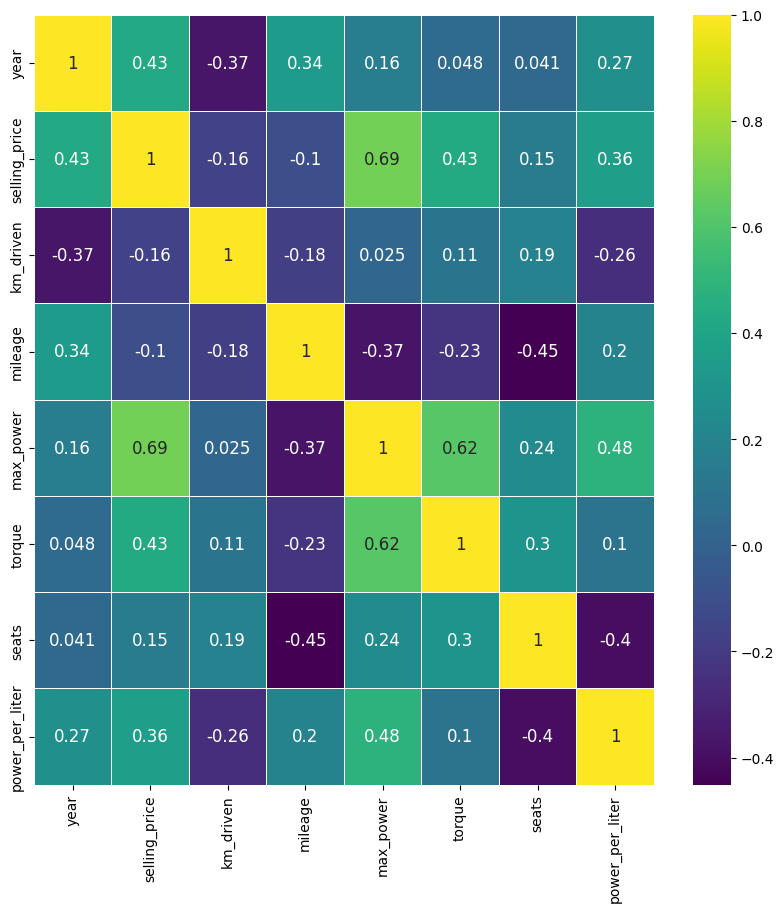

In [266]:
fig , ax = plt.subplots(figsize = (10,10))

sns.heatmap(df_train_eng.corr(numeric_only=True),
            linewidths=0.5, annot=True,cmap='viridis',
            linecolor="white", annot_kws = {'size':12})

##### 2. Логарифмирование признаков

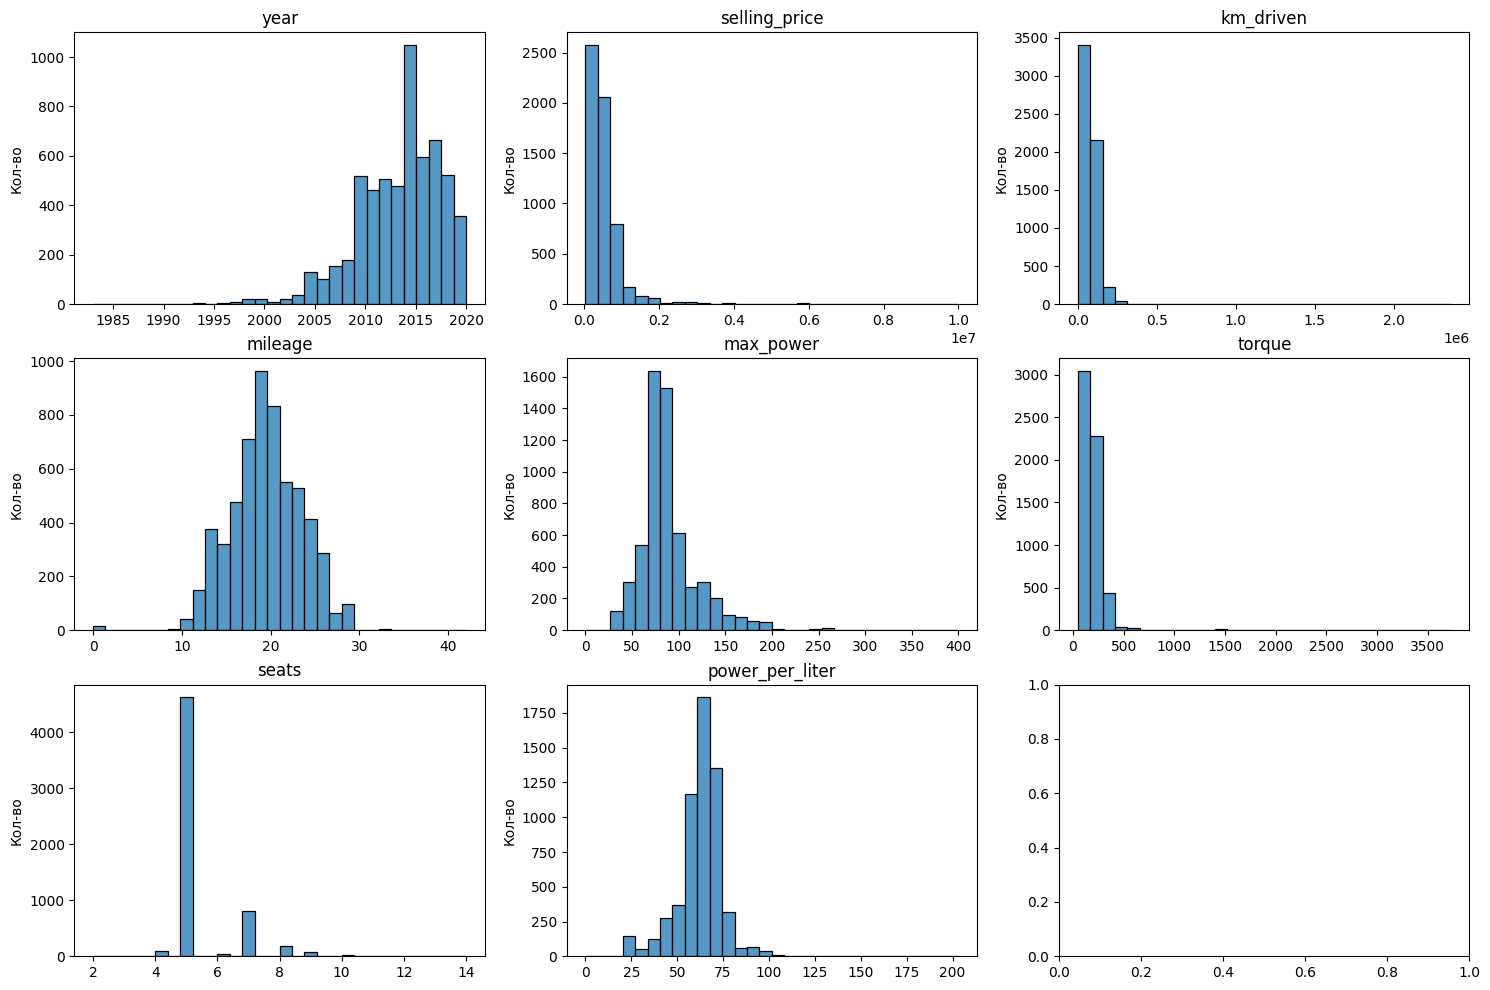

In [267]:
num = df_train_eng.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num):
    sns.histplot(data=df_train_eng, x=col, ax=axes[i], bins=30)

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Кол-во")

по графикам заметно, что стоит прологарифмировать selling_price, km_driven, torque, power_per_liter, max_power т.к. заметны большие скосы и распределения далеки от нормальных

In [268]:
log_list = ['selling_price', 'km_driven', 'torque', 'max_power', 'power_per_liter']

df_train_log = df_train_eng.copy()
df_test_log = df_test_eng.copy()

for i in log_list:
  df_train_log[f'{i}_log'] = np.log1p(df_train_log[i])
  df_test_log[f'{i}_log'] = np.log1p(df_test_log[i])


df_train_log = df_train_log.drop(log_list, axis=1)
df_test_log = df_test_log.drop(log_list, axis=1)

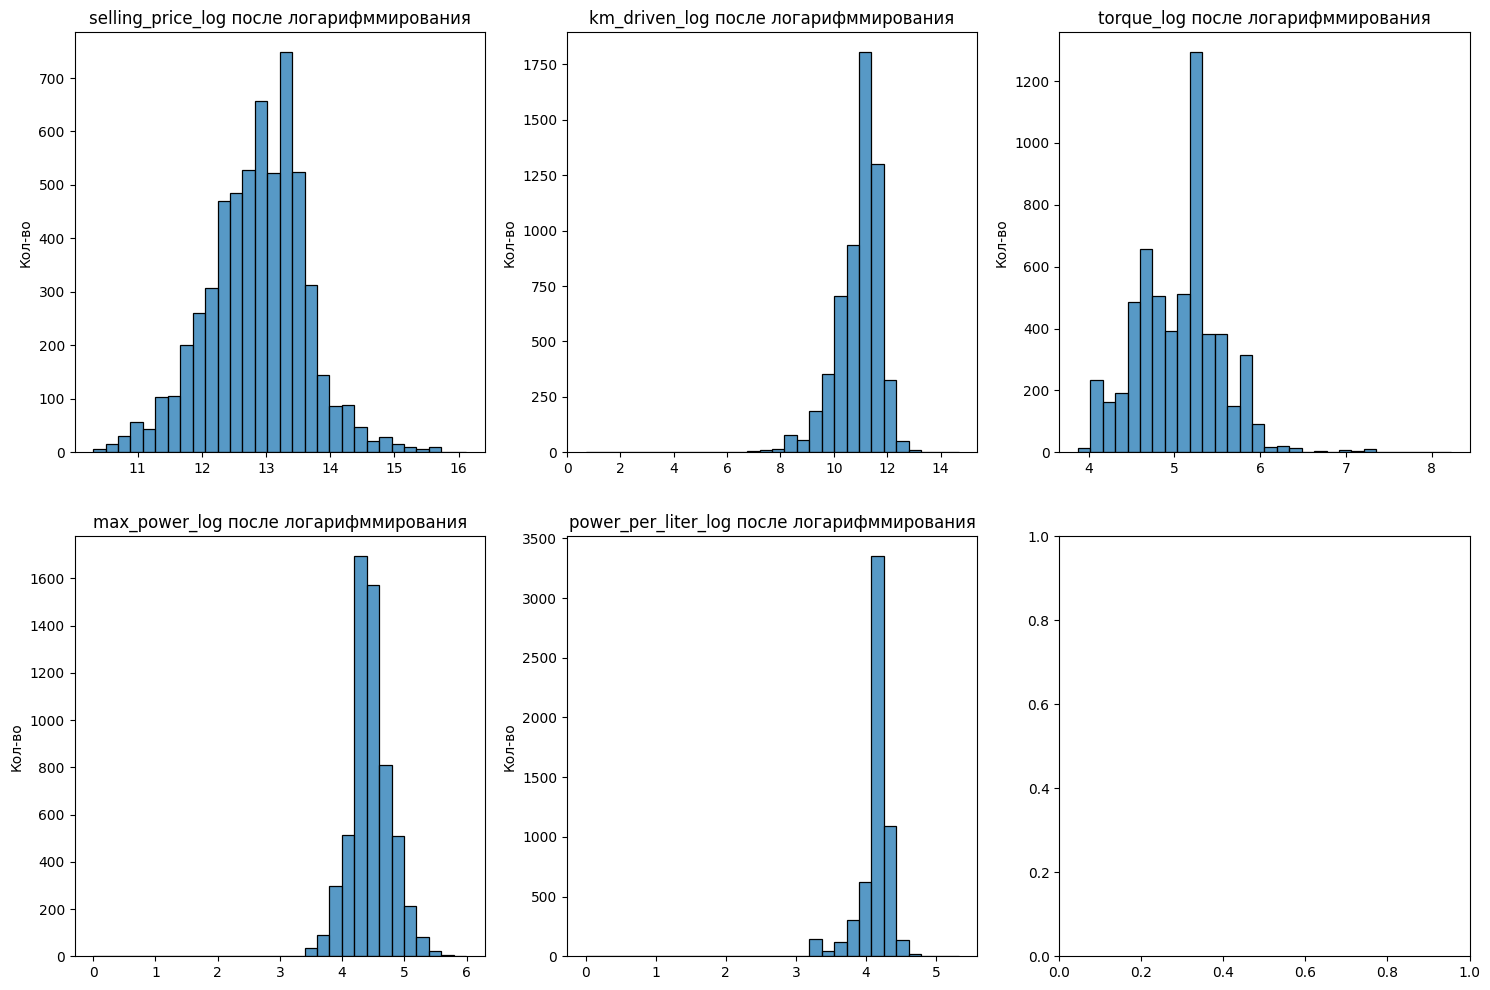

In [269]:
log_list_real = ['selling_price_log', 'km_driven_log', 'torque_log', 'max_power_log', 'power_per_liter_log']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(log_list_real):
    sns.histplot(data=df_train_log, x=col, ax=axes[i], bins=30)

    axes[i].set_title(f'{col} после логарифммирования')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Кол-во")

##### 3. Выбросы

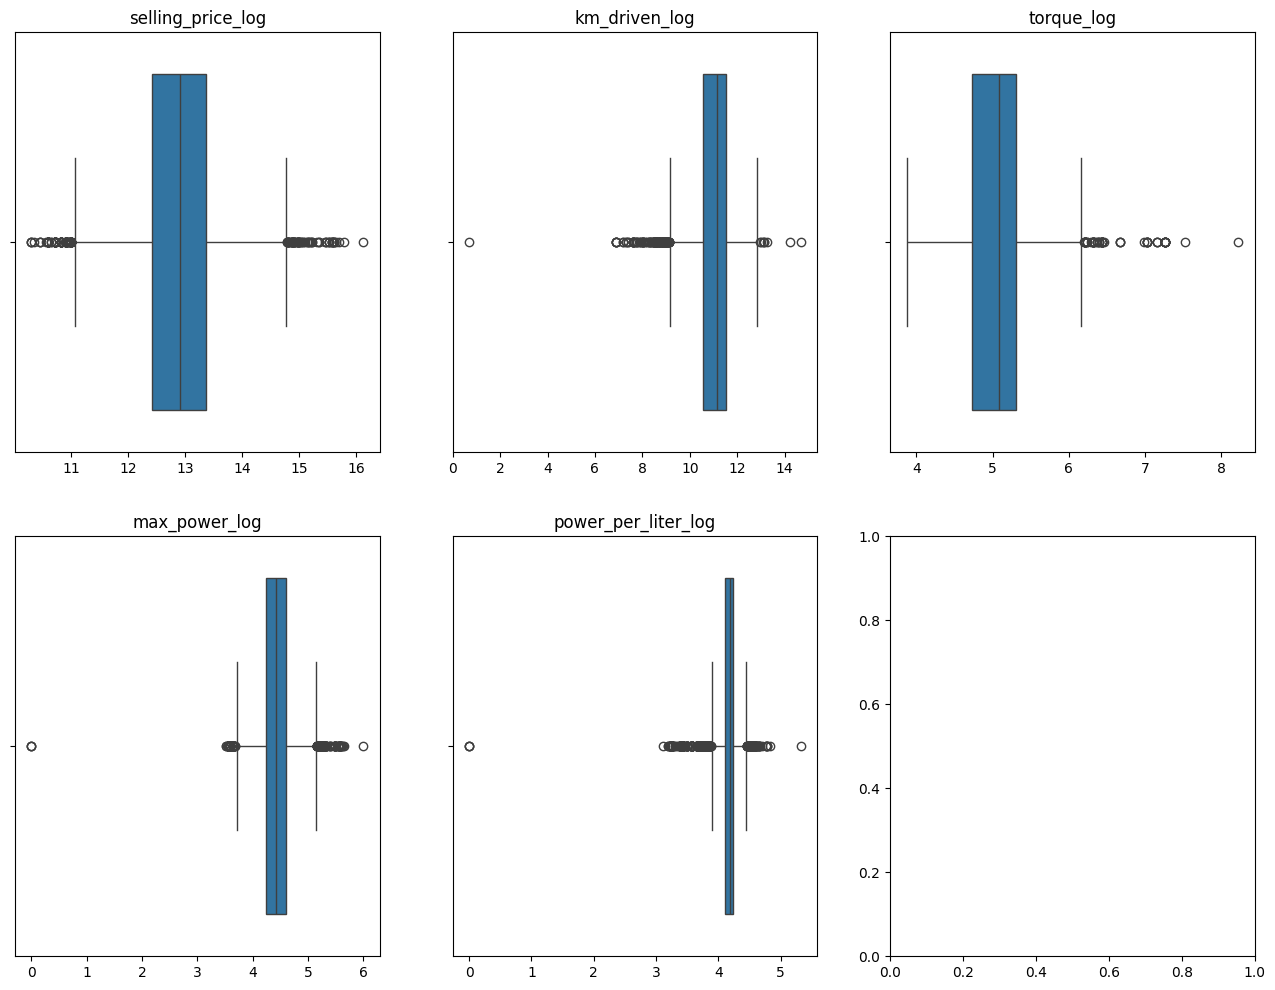

In [270]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(log_list_real):
      sns.boxplot(data=df_train_log, x=col, ax=axes[i])
      axes[i].set_title(col)
      axes[i].set_xlabel("")

In [271]:
df_train_clean = df_train_log.copy()
df_train_clean.shape

(5840, 13)

In [272]:
df_train_clean = df_train_clean[df_train_clean['max_power_log'] > 2.0]

df_train_clean = df_train_clean[df_train_clean['power_per_liter_log'] > 2.0]

df_train_clean = df_train_clean[df_train_clean['km_driven_log'] > 2.0]

df_train_clean.shape

(5836, 13)

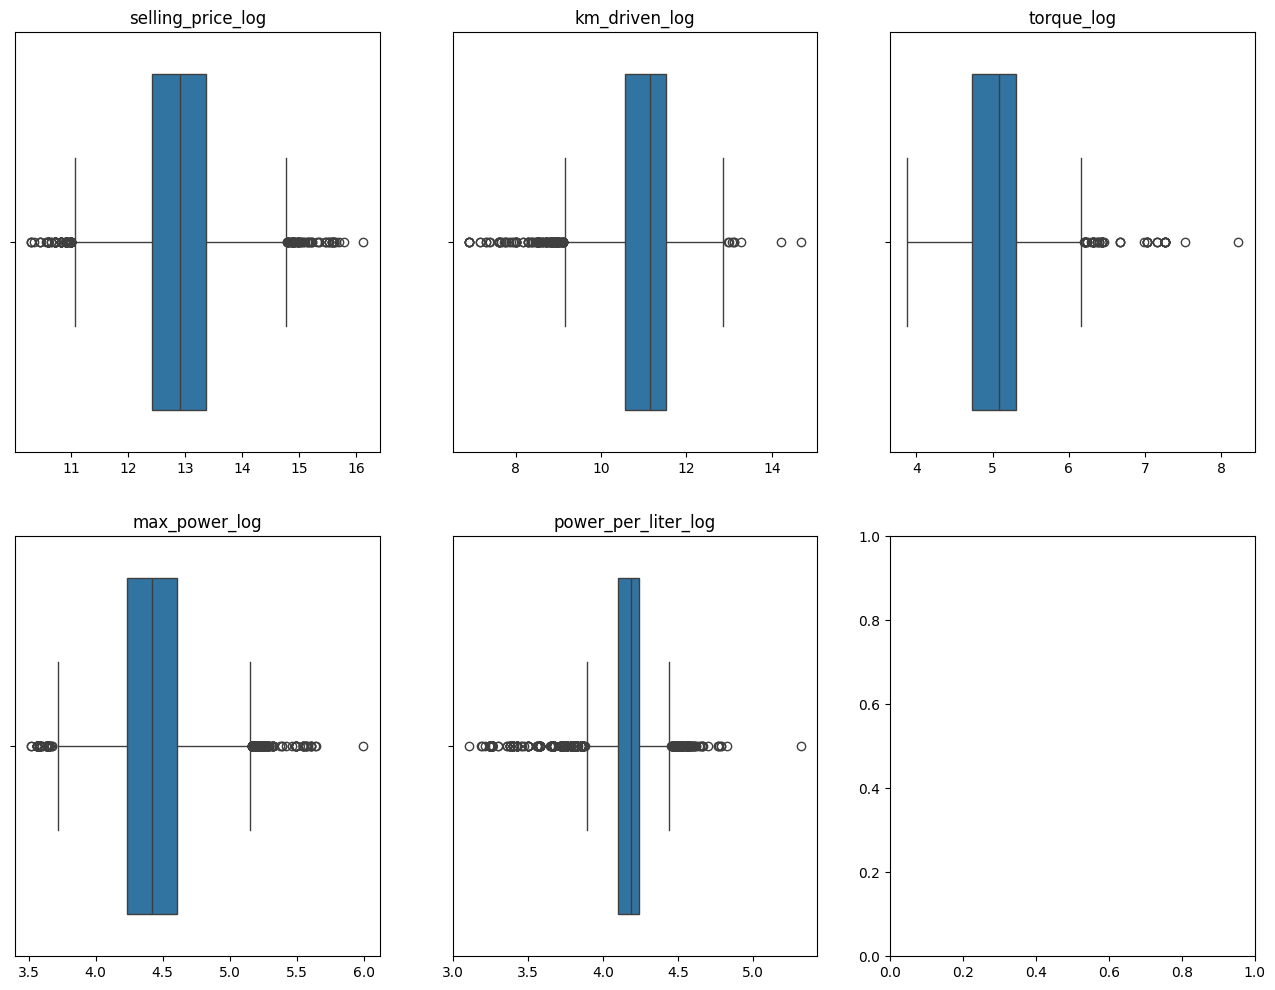

In [273]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(log_list_real):
      sns.boxplot(data=df_train_clean, x=col, ax=axes[i])
      axes[i].set_title(col)
      axes[i].set_xlabel("")

##### Обучение модели

Дублирую разбиаение ан категориальные признаки

In [274]:
pip install category_encoders

In [275]:
from category_encoders import TargetEncoder
from sklearn.preprocessing import OneHotEncoder

X_train_4 = df_train_clean.drop('selling_price_log', axis=1)
X_test_4 = df_test_log.drop('selling_price_log', axis=1)

y_train_4 = df_train_clean['selling_price_log']
y_test_4 = df_test_log['selling_price_log']

X_train_4['name'] = X_train_4['name'].str.split().str[0]
X_test_4['name'] = X_test_4['name'].str.split().str[0]

encoder = TargetEncoder(cols=['name'])

encoder.fit(X_train_4['name'], y_train_4)

X_train_4['name'] = encoder.transform(X_train_4['name'])

X_test_4['name'] = encoder.transform(X_test_4['name'])


X_train_4 = pd.get_dummies(X_train_4, columns=['fuel', 'transmission', 'seller_type', 'owner'], dtype=int, drop_first=True)
X_test_4 = pd.get_dummies(X_test_4, columns=['fuel', 'transmission', 'seller_type', 'owner'], dtype=int, drop_first=True)

seat_bins = [1, 2, 5, 8, 14]

seat_labels = ['2', '4-5', '6-8', '9-14']

X_train_4['seats_cat'] = pd.cut(X_train_4['seats'], bins=seat_bins, labels=seat_labels)
X_test_4['seats_cat'] = pd.cut(X_test_4['seats'], bins=seat_bins, labels=seat_labels)

X_train_4 = pd.get_dummies(X_train_4.drop(columns=['seats']), columns=['seats_cat'], prefix='seats', dtype=int, drop_first=True)
X_test_4 = pd.get_dummies(X_test_4.drop(columns=['seats']), columns=['seats_cat'], prefix='seats', dtype=int, drop_first=True)

X_test_4 = X_test_4.reindex(columns=X_train_4.columns, fill_value=0)

обучение модели

In [276]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

scaler = StandardScaler()
scaler.fit(X_train_4)

train_x_scaler_4 = scaler.transform(X_train_4)
test_x_scaler_4 = scaler.transform(X_test_4)

param_grid = {
    'alpha': [2, 5, 10, 20, 50, 100]
}

searcher = GridSearchCV(
    Ridge(),
    param_grid=param_grid,
    scoring="r2",
    cv=10)

searcher.fit(train_x_scaler_4, y_train_4)

best_alpha = searcher.best_params_["alpha"]

print("Best alpha = %.4f" % best_alpha)

best_4_model = searcher.best_estimator_
pred_train_4 = best_4_model.predict(train_x_scaler_4)
pred_test_4 = best_4_model.predict(test_x_scaler_4)

# убираем логарифым
y_train_original = np.expm1(y_train_4)
pred_train_original = np.expm1(pred_train_4)

y_test_original = np.expm1(y_test_4)
pred_test_original = np.expm1(pred_test_4)


print(f'MSE train: {round(MSE(y_train_original, pred_train_original), 2)}')
print(f'R2 train: {round(r2_score(y_train_original, pred_train_original), 2)}')
print(f'RMSE train: {round(RMSE(y_train_original, pred_train_original), 2)}')
print()
print(f'MSE test: {round(MSE(y_test_original, pred_test_original), 2)}')
print(f'R2 test: {round(r2_score(y_test_original, pred_test_original), 2)}')
print(f'RMSE test: {round(RMSE(y_test_original, pred_test_original), 2)}')

Best alpha = 10.0000
MSE train: 44408431382.34
R2 train: 0.85
RMSE train: 210733.08

MSE test: 113708568034.98
R2 test: 0.8
RMSE test: 337207.01


# **Часть 4. | Бизнесовая (1.5 балла)**

### **Задание 23 (0.75 балла)**

В мире бизнеса очень важно давать оценку качества модели, понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса

In [277]:
def business_metric(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    diff = (y_true - y_pred) / y_true

    good_predict = np.abs(diff) <= 0.1

    return np.mean(good_predict)

print(f'Линейная регрессия: {business_metric(y_test, pred_test)}')
print(f'Со скалированием: {business_metric(y_test, pred_test2)}')
print(f'Lasso: {business_metric(y_test, pred_test_lasso_best_alpha)}')
print(f'ElasticNet: {business_metric(y_test,  pred_test_elasticnet)}')
print(f'Ridge: {business_metric(y_test, pred_test_ridge)}')

print(f'Ridge после обработки: {business_metric(y_test_original, pred_test_original)}')

Линейная регрессия: 0.24
Со скалированием: 0.24
Lasso: 0.242
ElasticNet: 0.257
Ridge: 0.284
Ridge после обработки: 0.312


Лучшие модели - Ridge после обработки 31%

### **Задание 24 (0.75 балла)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, которая лучше всего решает задачу бизнеса



Можно взять за основу метрику RMSE, которая показывает отклонение от реальнйо стоимости, но учесть тот факт, что занижение стоимости - хуже, чем завышение

In [278]:
def your_business_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    dif = y_true - y_pred
# если разность полодительна, то модель оценила машину дешевле
    sq_loss = np.where(dif > 0,
        3 * (dif ** 2), #вводим штраф, умножая на коэффициент при занижении
        (dif ** 2) # при завышении просто берем квадрат
    )

    return np.sqrt(np.mean(sq_loss))

print(f'Линейная регрессия: {round(your_business_metrics(y_test, pred_test), 2)}')
print(f'Со скалированием: {round(your_business_metrics(y_test, pred_test2), 2)}')
print(f'Lasso: {round(your_business_metrics(y_test, pred_test_lasso_best_alpha), 2)}')
print(f'ElasticNet: {round(your_business_metrics(y_test,  pred_test_elasticnet), 2)}')
print(f'Ridge: {round(your_business_metrics(y_test, pred_test_ridge), 2)}')
print(f'Ridge после обработки: {round(your_business_metrics(y_test_original, pred_test_original),2)}')

Линейная регрессия: 796885.94
Со скалированием: 796885.94
Lasso: 798520.78
ElasticNet: 827698.53
Ridge: 679083.61
Ridge после обработки: 571134.04


лучше всего справляется Ridge после обработки

# **Часть 5 (12 баллов) | Создание интерактивного приложения на Streamlit**

### **Задание 25 (9 баллов)**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (3 балла)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (3 балла)
- Визуализировать веса обученной модели (3 балла)

Протестируйте приложение на адекватность и запишите демо работы сервиса (`gif` | `mp4` | …).

### **Задание 26 (3 балла). Оформление результатов**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории.

Под результатами понимаем следующее:

---

#### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```
5. **заполненный requirements.txt**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.

**Также необходимо приложить ссылку на развернутое в StreamlitHub приложение.**


### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном
* слабая или неполная аналитика в `.md`-файле
* беспорядок в ноутбуке или неясная логика вычислений
* отсутствие файлов
* невыполнение любых других обязательных требований, указанных в описании задания
* Streamlit-приложение не развернуто / не запускается

## Заключительная часть

Надеемся, вы честно проделали все пункты, а не просто пролистали досюда. Теперь можно отдохнуть и похвалить себя. Но пожалуйста, не стоит награждать себя до того, как закончите работать над домашкой :)


Поделитесь впечатлениями о задании:

    (ваши эмоции от домашней работы)

P.S Удачного кодинга!  
Пейте латте маккиато, пишите красивый Python!!